### Import libraries

In [1]:
import numpy as np

from networkx.readwrite import json_graph

import seaborn as sns
import matplotlib.pyplot as plt

import json
import os

### 1.- Execution time

In [ ]:
# Tiempo de ejecución de LiNGAMValidation (fast vs slow)
def plot_history_hits(history):
    sns.set(style="darkgrid")
    sns.lineplot(x=range(3, len(history['slow_time']) + 3), y=history['slow_time'], marker='o', label='Full algorithm')
    sns.lineplot(x=range(3, len(history['fast_time']) + 3), y=history['fast_time'], marker='o', label='Fast algorithm')
    plt.yscale('log')
    plt.xlabel('Number of nodes')
    plt.ylabel('Time (s)')
    plt.title('Execution time of NA-LiNGAM')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()
    plt.close()

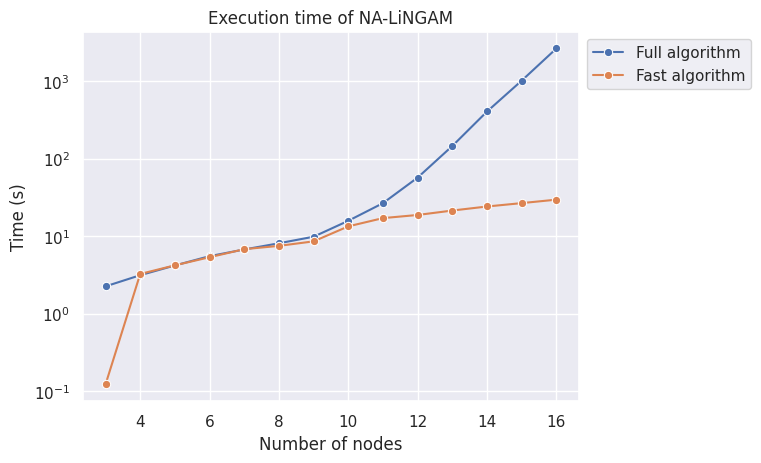

In [ ]:
with open('graph_metrics/execution_time.json') as f:
    execution_time_history = json.load(f)
plot_history_hits(execution_time_history)

### 2.- States accuracy

In [ ]:
# Gráfica de elementos del estado (variables) acertados por LiNGAMValidation
def plot_history_variable_accuracy(history):
    sns.set(style="darkgrid")
    sns.lineplot(x=range(len(history['accuracy'])), y=history['accuracy'], marker='o', label='Fast algorithm accuracy')
    sns.lineplot(x=range(len(history['accuracy_slow'])), y=history['accuracy_slow'], marker='o', label='Full algorithm accuracy')
    plt.xlabel('Number of noise nodes')
    plt.ylabel('Accuracy')
    plt.title('Selected variables accuracy')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()
    plt.close()

In [ ]:
# Gráfica de estados acertados por LiNGAMValidation
def plot_history_hits(history):
    sns.set(style="darkgrid")
    sns.lineplot(x=range(len(history['hits'])), y=history['hits'], marker='o', label='Fast algorithm hits')
    sns.lineplot(x=range(len(history['hits_slow'])), y=history['hits_slow'], marker='o', label='Full algorithm hits')
    plt.xlabel('Number of noise nodes')
    plt.ylabel('Accuracy')
    # plt.ylim(0, 1.05)
    plt.title('States accuracy')
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.show()
    plt.close()

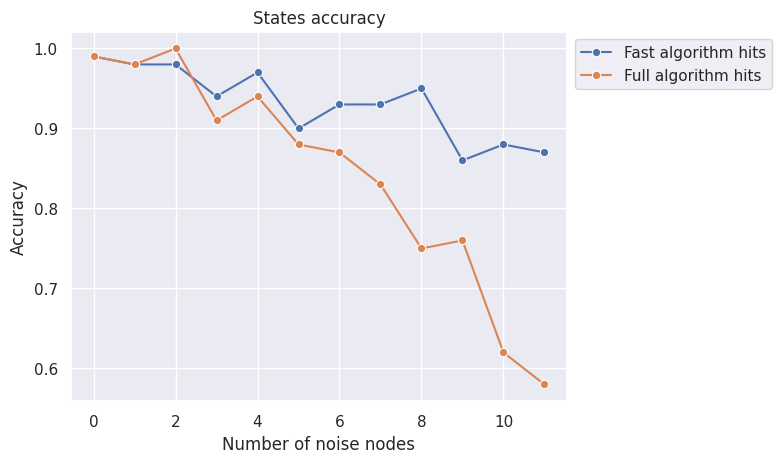

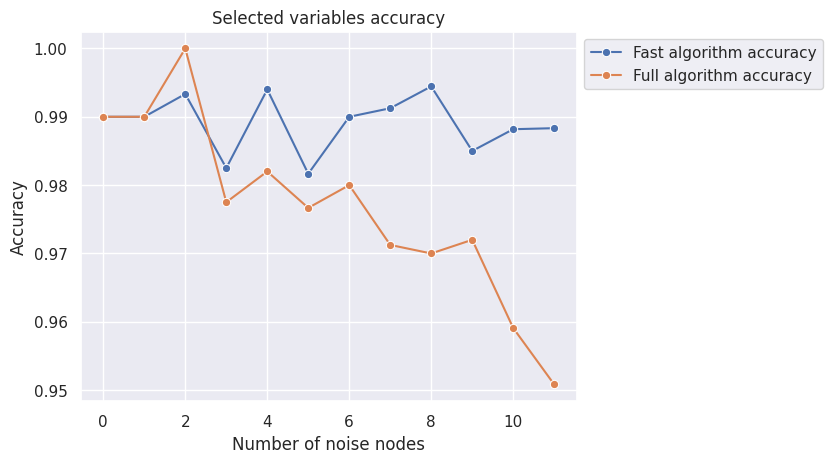

In [ ]:
with open('graph_metrics/synthetic_accuracy_hits_lingam_slow_100_20.json') as f:
    synthetic_accuracy_hits = json.load(f)
plot_history_hits(synthetic_accuracy_hits)
plot_history_variable_accuracy(synthetic_accuracy_hits)

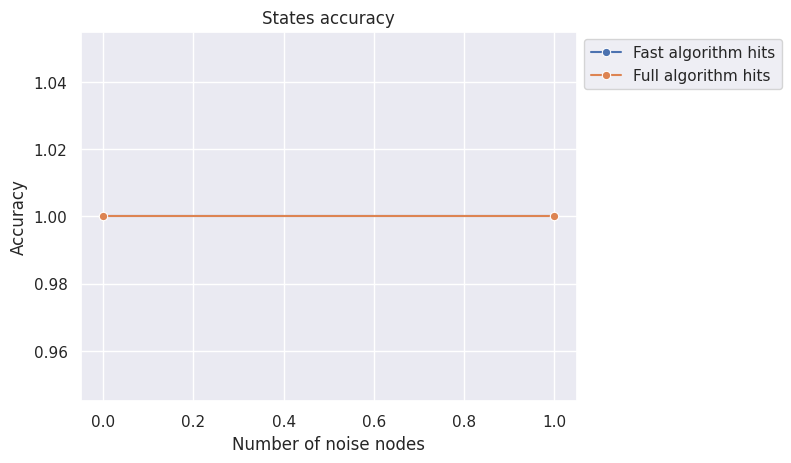

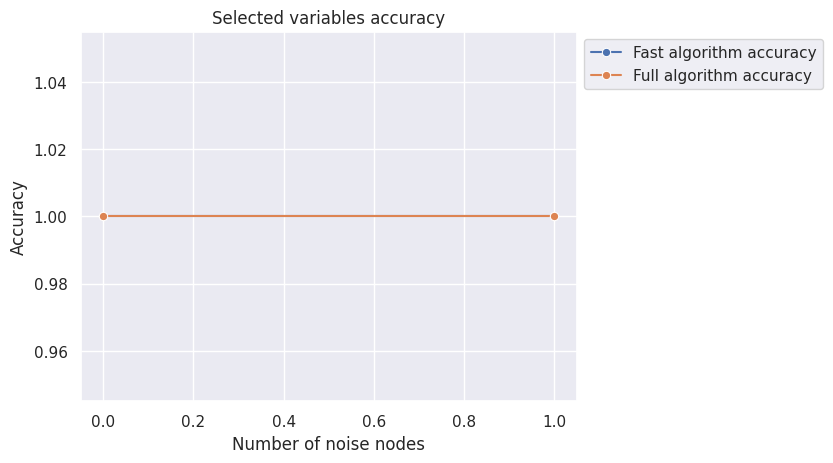

In [ ]:
with open('graph_metrics/real_accuracy_hits_lingam_slow_20_20.json') as f:
    real_accuracy_hits = json.load(f)
plot_history_hits(real_accuracy_hits)
plot_history_variable_accuracy(real_accuracy_hits)

### 3.- Causal discovery results

In [ ]:
def load_graph_from_json(file_path):
    with open(file_path, 'r') as f:
        data = json.load(f)
    return json_graph.node_link_graph(data)

In [ ]:
def verify_graph(graphs_path):
    folder_list = os.listdir(graphs_path)

    real_graph = load_graph_from_json(graphs_path + '/' + folder_list[-1] + '/' + os.listdir(graphs_path + '/' + folder_list[-1])[0])

    graphs_models_dict = {}

    for folder in folder_list[:-1]:
        graphs_dict = {}

        for noise_level in range(21):
            graphs_dict[str(noise_level)] = None

        file_list = os.listdir(graphs_path + '/' + folder)
        for file in file_list:
            name_dir = graphs_path + '/' + folder + '/' + file
            try:
                noise_level = file.split('_')[2]
                if graphs_dict[noise_level] is None:
                    graphs_dict[noise_level] = []
                graphs_dict[noise_level].append(load_graph_from_json(name_dir))
            except:
                print(f'Error loading and preprocessing file {file} in folder {folder}. Skipping this file.')

        graphs_models_dict[folder] = graphs_dict

    return real_graph, graphs_models_dict

In [ ]:
real_graph, graphs_models_dict = verify_graph('results_real/results_lingam_20_noise_20_iter')